In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import geopandas as gpd

In [2]:
gdf = gpd.read_file(
    Path.cwd().parent / 'resources' / 'regions_onshore_base_s_50.geojson'
).set_index('name')

ERROR 1: PROJ: proj_create_from_database: Open of /home/lukas/micromamba/envs/pypsa-eur/share/proj failed


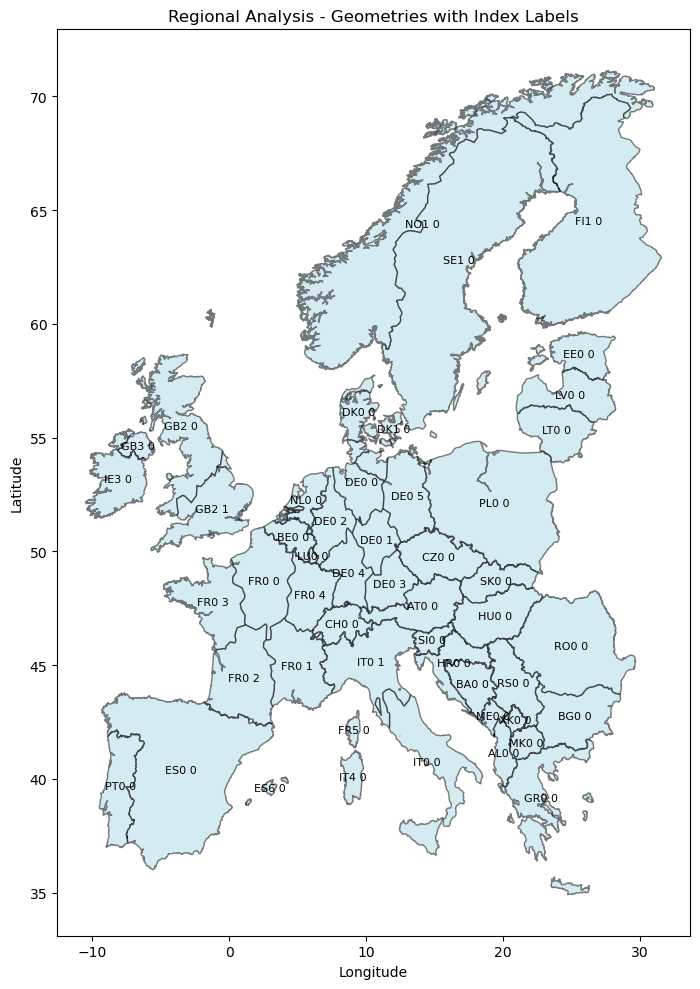

In [4]:
fig, ax = plt.subplots(figsize=(15, 10))
gdf.plot(ax=ax, edgecolor='black', facecolor='lightblue', alpha=0.5)

# Annotate each geometry with its index value
for idx, row in gdf.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(text=idx, xy=(centroid.x, centroid.y), 
                ha='center', va='center', fontsize=8)

plt.title('Regional Analysis - Geometries with Index Labels')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

In [5]:
gdf.index

Index(['AL0 0', 'AT0 0', 'BA0 0', 'BE0 0', 'BG0 0', 'CH0 0', 'CZ0 0', 'DE0 0',
       'DE0 1', 'DE0 2', 'DE0 3', 'DE0 4', 'DE0 5', 'DK0 0', 'DK1 0', 'EE0 0',
       'ES0 0', 'ES6 0', 'FI1 0', 'FR0 0', 'FR0 1', 'FR0 2', 'FR0 3', 'FR0 4',
       'FR5 0', 'GB2 0', 'GB2 1', 'GB3 0', 'GR0 0', 'HR0 0', 'HU0 0', 'IE3 0',
       'IT0 0', 'IT0 1', 'IT4 0', 'LT0 0', 'LU0 0', 'LV0 0', 'ME0 0', 'MK0 0',
       'NL0 0', 'NO1 0', 'PL0 0', 'PT0 0', 'RO0 0', 'RS0 0', 'SE1 0', 'SI0 0',
       'SK0 0', 'XK0 0'],
      dtype='object', name='name')

In [ ]:
region_group = {
    # Alps / DACH-ish (non-DE)
    "AT0 0": "Alps (AT+CH)",
    "CH0 0": "Alps (AT+CH)",

    # Germany (split nodes)
    "DE0 0": "Germany",
    "DE0 1": "Germany",
    "DE0 2": "Germany",
    "DE0 3": "Germany",
    "DE0 4": "Germany",
    "DE0 5": "Germany",

    # France (split nodes)
    "FR0 0": "France",
    "FR0 1": "France",
    "FR0 2": "France",
    "FR0 3": "France",
    "FR0 4": "France",
    "FR5 0": "France",

    # Italy (split nodes)
    "IT0 0": "Italy",
    "IT0 1": "Italy",
    "IT4 0": "Italy",

    # Iberia
    "ES0 0": "Iberia",
    "ES6 0": "Iberia",
    "PT0 0": "Iberia",

    # Benelux
    "BE0 0": "Benelux",
    "NL0 0": "Benelux",
    "LU0 0": "Benelux",

    # British Isles
    "GB2 0": "British Isles",
    "GB2 1": "British Isles",
    "GB3 0": "British Isles",
    "IE3 0": "British Isles",

    # Nordics / Scandinavia
    "DK0 0": "Nordics",
    "DK1 0": "Nordics",
    "NO1 0": "Nordics",
    "SE1 0": "Nordics",
    "FI1 0": "Nordics",

    # Central & Eastern Europe (incl Baltics)
    "CZ0 0": "Central & Eastern Europe",
    "PL0 0": "Central & Eastern Europe",
    "SK0 0": "Central & Eastern Europe",
    "HU0 0": "Central & Eastern Europe",
    "RO0 0": "Central & Eastern Europe",
    "BG0 0": "Central & Eastern Europe",
    "SI0 0": "Central & Eastern Europe",
    "HR0 0": "Central & Eastern Europe",
    "EE0 0": "Central & Eastern Europe",
    "LV0 0": "Central & Eastern Europe",
    "LT0 0": "Central & Eastern Europe",

    # Balkans & Greece (Western Balkans + GR)
    "AL0 0": "Balkans & Greece",
    "BA0 0": "Balkans & Greece",
    "ME0 0": "Balkans & Greece",
    "MK0 0": "Balkans & Greece",
    "RS0 0": "Balkans & Greece",
    "XK0 0": "Balkans & Greece",
    "GR0 0": "Balkans & Greece",
}

In [15]:
nc = pd.read_csv(
    Path.cwd().parent / 'results' / 'csvs' / 'nodal_capacities.csv', header=list(range(5)), index_col=[0,1,2]
)
nc.columns = nc.columns.get_level_values(-1)

In [21]:
import pandas as pd

def groupby_sum_with_mapping(obj, mapping: dict, level):
    """
    Apply a mapping dict to ONE index level and then groupby-sum.

    - Values at `level` that are keys in `mapping` are replaced by mapping[value].
    - Values not in `mapping` remain unchanged.
    - Then aggregates (sum) any duplicates created by the mapping.

    Works for both pd.Series and pd.DataFrame.
    """
    if not isinstance(obj, (pd.Series, pd.DataFrame)):
        raise TypeError("obj must be a pandas Series or DataFrame")

    idx = obj.index

    # --- Single-level Index case ---
    if not isinstance(idx, pd.MultiIndex):
        new_index = idx.map(lambda x: mapping.get(x, x))
        out = obj.copy()
        out.index = pd.Index(new_index, name=idx.name)
        return out.groupby(level=0, sort=False).sum()

    # --- MultiIndex case ---
    level_num = idx._get_level_number(level)

    new_arrays = []
    for i in range(idx.nlevels):
        lv = idx.get_level_values(i)
        if i == level_num:
            lv = lv.map(lambda x: mapping.get(x, x))
        new_arrays.append(lv)

    new_index = pd.MultiIndex.from_arrays(new_arrays, names=idx.names)

    out = obj.copy()
    out.index = new_index

    # groupby all levels, sum duplicates
    return out.groupby(level=list(range(new_index.nlevels)), sort=False).sum()

In [23]:
s = pd.Series(
    [1, 2, 3, 4],
    index=pd.MultiIndex.from_tuples(
        [("DE", "gas"), ("DE", "coal"), ("FR", "gas"), ("FR", "oil")],
        names=["country", "fuel"]
    )
)

mapping = {"gas": "fossil", "coal": "fossil"}

print(s)

groupby_sum_with_mapping(s, mapping, level="fuel")

country  fuel
DE       gas     1
         coal    2
FR       gas     3
         oil     4
dtype: int64


country  fuel  
DE       fossil    3
FR       fossil    3
         oil       4
dtype: int64

In [32]:
(nc['1500'].groupby(level=2).sum() - nc['4000'].groupby(level=2).sum()).abs().sort_values(ascending=False).head(60)

carrier
coal                                                          1.023314e+10
co2 sequestered                                               2.070935e+07
H2 Store                                                      1.366325e+07
ammonia store                                                 9.526991e+06
methanol                                                      5.622096e+06
urban central solar thermal                                   1.672276e+06
co2 stored                                                    1.431572e+06
rural solar thermal                                           6.195039e+05
urban decentral solar thermal                                 4.701903e+05
H2 Electrolysis                                               2.584385e+05
electricity distribution grid                                 1.606484e+05
urban central gas boiler                                      1.477959e+05
Combined-Cycle Gas                                            1.334296e+05
gas              

In [18]:
list(nc.index.get_level_values(2).unique())

['Onshore Wind',
 'Run of River',
 'Solar',
 'biogas',
 'rural heat vent',
 'rural solar thermal',
 'solar-hsat',
 'solid biomass',
 'unsustainable solid biomass',
 'urban central heat vent',
 'urban central solar thermal',
 'urban decentral heat vent',
 'urban decentral solar thermal',
 'gas',
 'unsustainable biogas',
 'unsustainable bioliquids',
 'Offshore Wind (AC)',
 'nuclear',
 'Offshore Wind (DC)',
 'Offshore Wind (Floating)',
 'co2-ets',
 'coal',
 'oil primary',
 'AC',
 'BEV charger',
 'CO2 pipeline',
 'Combined-Cycle Gas',
 'Fischer-Tropsch',
 'H2 Electrolysis',
 'HVC to air',
 'Haber-Bosch',
 'Open-Cycle Gas',
 'SMR',
 'SMR CC',
 'Sabatier',
 'V2G',
 'biogas to gas',
 'biomass to liquid',
 'biomass-to-methanol',
 'electricity distribution grid',
 'electrobiofuels',
 'gas for industry',
 'gas for industry CC',
 'gas pipeline new',
 'heat100-200 industry electric boiler steam',
 'heat100-200 industry gas',
 'heat100-200 industry gas CC',
 'heat100-200 industry industrial heat pu

In [33]:
groupers = {
    'power': {
        'Offshore Wind (AC)': 'Offshore Wind',
        'Offshore Wind (DC)': 'Offshore Wind',
        'Offshore Wind (Floating)': 'Offshore Wind',
        'OCGT': 'Gas Turbine',
        'CCGT': 'Gas Turbine',
        'Solar': 'Solar PV',
        'solar-hsat': 'Solar PV',
        'Battery Storage': 'battery',
        'home battery': 'home battery',
    },
    'heating': {
        'rural ground heat pump accelerated 0': 'heat pump',
        'rural ground heat pump accelerated 1': 'heat pump',
        'rural ground heat pump accelerated 2': 'heat pump',
        'rural ground heat pump accelerated 3': 'heat pump',
        'rural ground heat pump accelerated 4': 'heat pump',
        'urban decentral air heat pump accelerated 0': 'heat pump',
        'urban decentral air heat pump accelerated 1': 'heat pump',
        'urban decentral air heat pump accelerated 2': 'heat pump',
        'urban decentral air heat pump accelerated 3': 'heat pump',
        'urban decentral air heat pump accelerated 4': 'heat pump',
        'rural ground heat pump': 'heat pump',
        'urban decentral air heat pump': 'heat pump',
        'rural air heat pump': 'heat pump',
        'urban decentral gas boiler': 'gas boiler',
        'rural gas boiler': 'gas boiler',
        'rural biomass boiler': 'biomass boiler',
        'rural solar thermal': 'solar thermal',
        'urban decentral solar thermal': 'solar thermal',
        'urban decentral biomass boiler': 'biomass boiler',
    },
    'central heating': {
        'urban central air heat pump': 'heat pump',
        'urban central gas CHP': 'gas CHP',
        'urban central gas boiler': 'gas boiler',
        'urban central gas CHP CC': 'gas CHP',
        'urban central solid biomass CHP': 'biomass CHP',
        'urban central solid biomass CHP CC': 'biomass CHP',
    },
    'industry100-500': {
        'heat100-200 industry electric boiler steam': 'electric boiler',
        'heat100-200 industry gas': 'gas boiler',
        'heat100-200 industry gas CC': 'gas boiler',
        'heat100-200 industry industrial heat pump high temperature': 'heat pump',
        'heat100-200 industry solid biomass': 'biomass boiler',
        'heat100-200 industry solid biomass CC': 'biomass boiler',
        'heat200-500 industry gas': 'gas boiler',
        'heat200-500 industry gas CC': 'gas boiler',
        'heat200-500 industry hydrogen': 'hydrogen boiler',
        'heat200-500 industry solid biomass': 'biomass boiler',
        'heat200-500 industry solid biomass CC': 'biomass boiler',
    },
    'industry>500': {
        'heat>500 industry gas': 'gas boiler',
        'heat>500 industry gas CC': 'gas boiler',
        'heat>500 industry hydrogen': 'hydrogen boiler',
    },
    'conversion': {
        'SMR': 'SMR',
        'SMR CC': 'SMR',
        'H2 Electrolysis': 'electrolysis',
        'biogas to gas': 'biogas to gas',
        'methanolisation': 'methanolisation',
        'Haber-Bosch': 'Haber-Bosch',
    }
}

